In [33]:
import json
import torch
import matplotlib.pyplot as plt
import numpy as np
import os
import glob
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import h5py
import pandas as pd

import sys
sys.path.append('/home/kurgyis/Research/VideoAnalysisTools/src/')
from behavioral_autoencoder.models import AutoEncoder

In [35]:
training_folder = [
    'kd115_twNew_20221206_115814_2026-06-26_21-01-12',
    'kd115_twNew_20221206_115814_2026-07-06_18-12-13'
]

use_folder = training_folder[1]

inference_data_path = f'/home/kurgyis/Research/VideoAnalysisTools/data/checkpoints/kd115/{use_folder}/kd115_twNew_20221206_115814_latents_recons.h5'
original_data_path = '/home/kurgyis/Research/VideoAnalysisTools/data/kd115_twNew_20221206_115814/kd115_twNew_20221206_115814_side_newcrop.h5'

inference_data = h5py.File(inference_data_path, 'r')
original_data = h5py.File(original_data_path, 'r')

In [36]:
figfolder = '/home/kurgyis/Research/VideoAnalysisTools/figures/'

In [37]:
inference_data.keys(), original_data.keys()

(<KeysViewHDF5 ['frame_indices', 'latents', 'mean_frame', 'reconstructions', 'trial_ids']>,
 <KeysViewHDF5 ['filenames', 'frames', 'id_within_trial', 'trial_ids']>)

In [38]:
inference_data['reconstructions'].shape

(361521, 120, 112)

In [39]:
(inference_data['reconstructions'][0:2048,].min()),(inference_data['reconstructions'][0:2048,].max()), (inference_data['reconstructions'][0:2048,].mean())

(np.uint8(34), np.uint8(255), np.float64(108.90126480829149))

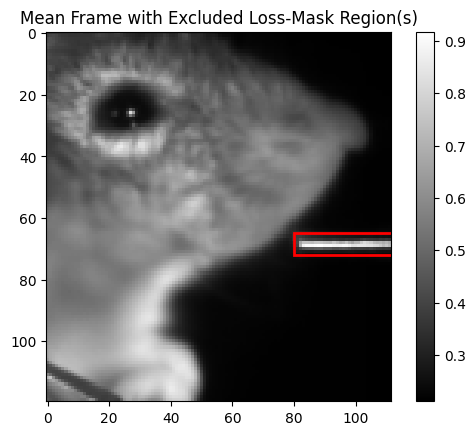

In [40]:
import matplotlib.patches as patches

# Path to the env config that defines the loss mask f
# or this session (edit if needed)
mask_config_path = '/home/kurgyis/Research/VideoAnalysisTools/configs/aws_config.json'
with open(mask_config_path, 'r') as f:
    mask_config = json.load(f)
exclude_regions = mask_config['dataset'].get('loss_mask_exclude_regions', [])

fig, ax = plt.subplots()
ax.imshow(inference_data['mean_frame'][:].squeeze(),
cmap='gray')
for region in exclude_regions:
    rect = patches.Rectangle(
        (region['left'], region['top']),
        region['right'] - region['left'],
        region['bottom'] - region['top'],
        linewidth=2, edgecolor='red', facecolor='none'
    )
    ax.add_patch(rect)
ax.set_title('Mean Frame with Excluded Loss-Mask Region(s)')
plt.colorbar(ax.images[0], ax=ax)
#plt.savefig(os.path.join(figfolder, 'mean_frame_with_excluded_loss_mask_regions.png'), bbox_inches='tight', dpi=300)

plt.show()

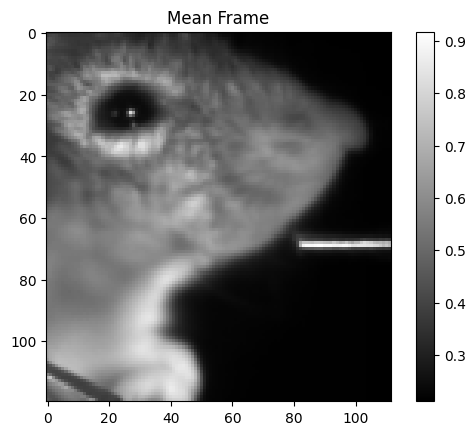

In [7]:
plt.imshow(inference_data['mean_frame'][:].squeeze(), cmap='gray')
plt.colorbar()
plt.title('Mean Frame')
plt.savefig(os.path.join(figfolder, 'mean_frame_newcrop.png'), bbox_inches='tight', dpi=300)
plt.show()

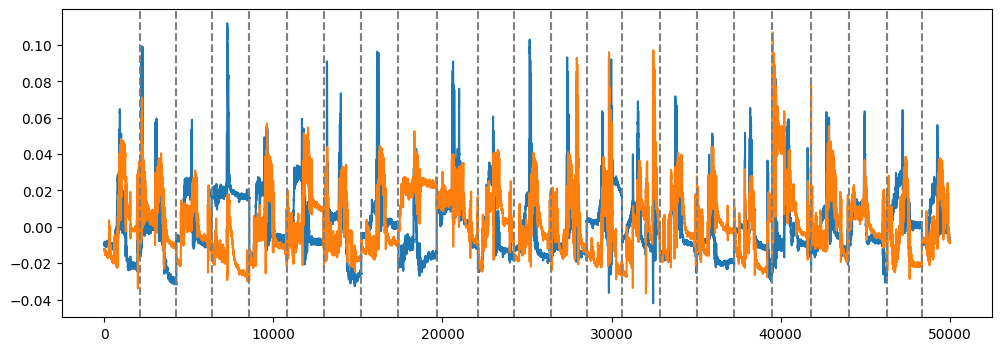

In [41]:
plt.figure(figsize=(12, 4))
plt.plot(inference_data['latents'][:50000].squeeze()[:,4])
plt.plot(inference_data['latents'][:50000].squeeze()[:,15])
for xx_lim in np.where(np.diff(inference_data['trial_ids'][:50000]) != 0)[0]:
    plt.axvline(xx_lim, color='gray', linestyle='--')

In [44]:
with open('/home/kurgyis/Research/VideoAnalysisTools/configs/ae_config.json', 'r') as f:
        config = json.load(f)

ae = AutoEncoder(config['model'])
checkpoint = torch.load(f'/home/kurgyis/Research/VideoAnalysisTools/data/checkpoints/kd115/{use_folder}/checkpoint_epoch_5999.pt', map_location='cpu', weights_only=False)
#checkpoint = torch.load('/home/kurgyis/Research/VideoAnalysisTools/data/checkpoints/kd115/kd115_twNew_20221206_115814_2026-06-23_19-07-46/checkpoint_epoch_2499.pt', map_location='cpu', weights_only=False)
ae.load_state_dict(checkpoint['model_state_dict'])


<All keys matched successfully>

In [45]:
checkpoint['val_losses'][-1]

0.0010625222676035229

In [46]:
checkpoint['val_latent_losses'][-1]

0.00490960325060188

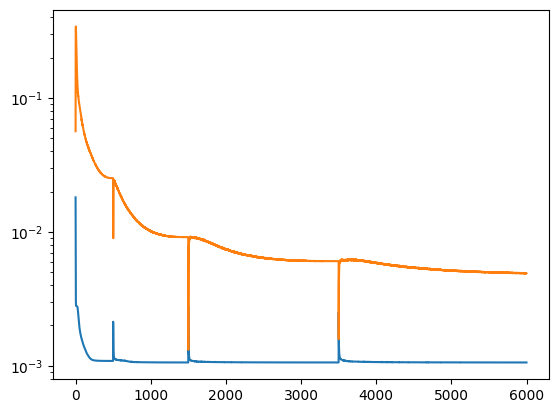

In [47]:
plt.plot(checkpoint['val_recon_losses'])
plt.plot(checkpoint['val_latent_losses'])
plt.yscale('log')

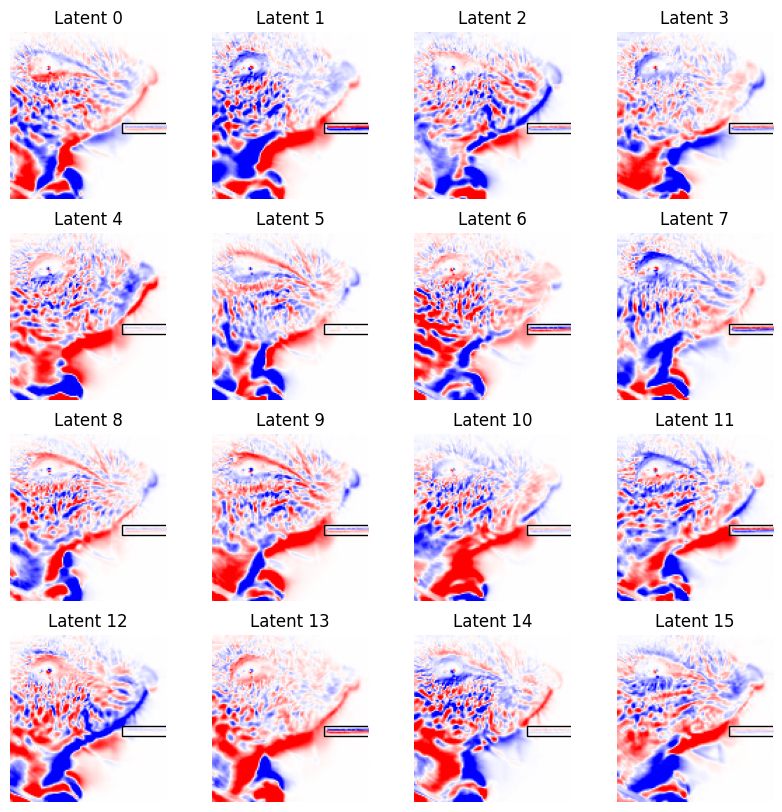

In [49]:
f, axs = plt.subplots(4, 4, figsize=(10, 10))
axs = axs.flatten()

for i in range(16):
    input = torch.zeros((1,1,16))
    input[0,0,i] = 1

    with torch.no_grad():
        latent_image = ae.decoder(input)
        latent_image = latent_image.squeeze().numpy()
        axs[i].imshow(latent_image, cmap='bwr', vmin=-1, vmax=1)
        axs[i].set_title(f"Latent {i}")
        axs[i].axis('off')

    for region in exclude_regions:
        rect = patches.Rectangle(
            (region['left'], region['top']),
            region['right'] - region['left'],
            region['bottom'] - region['top'],
            linewidth=1, edgecolor='k', facecolor='none'
        )
    axs[i].add_patch(rect)

#plt.savefig(os.path.join(figfolder, 'decoder_latent_visualization_sequence_newcrop_v2.png'), bbox_inches='tight', dpi=300)


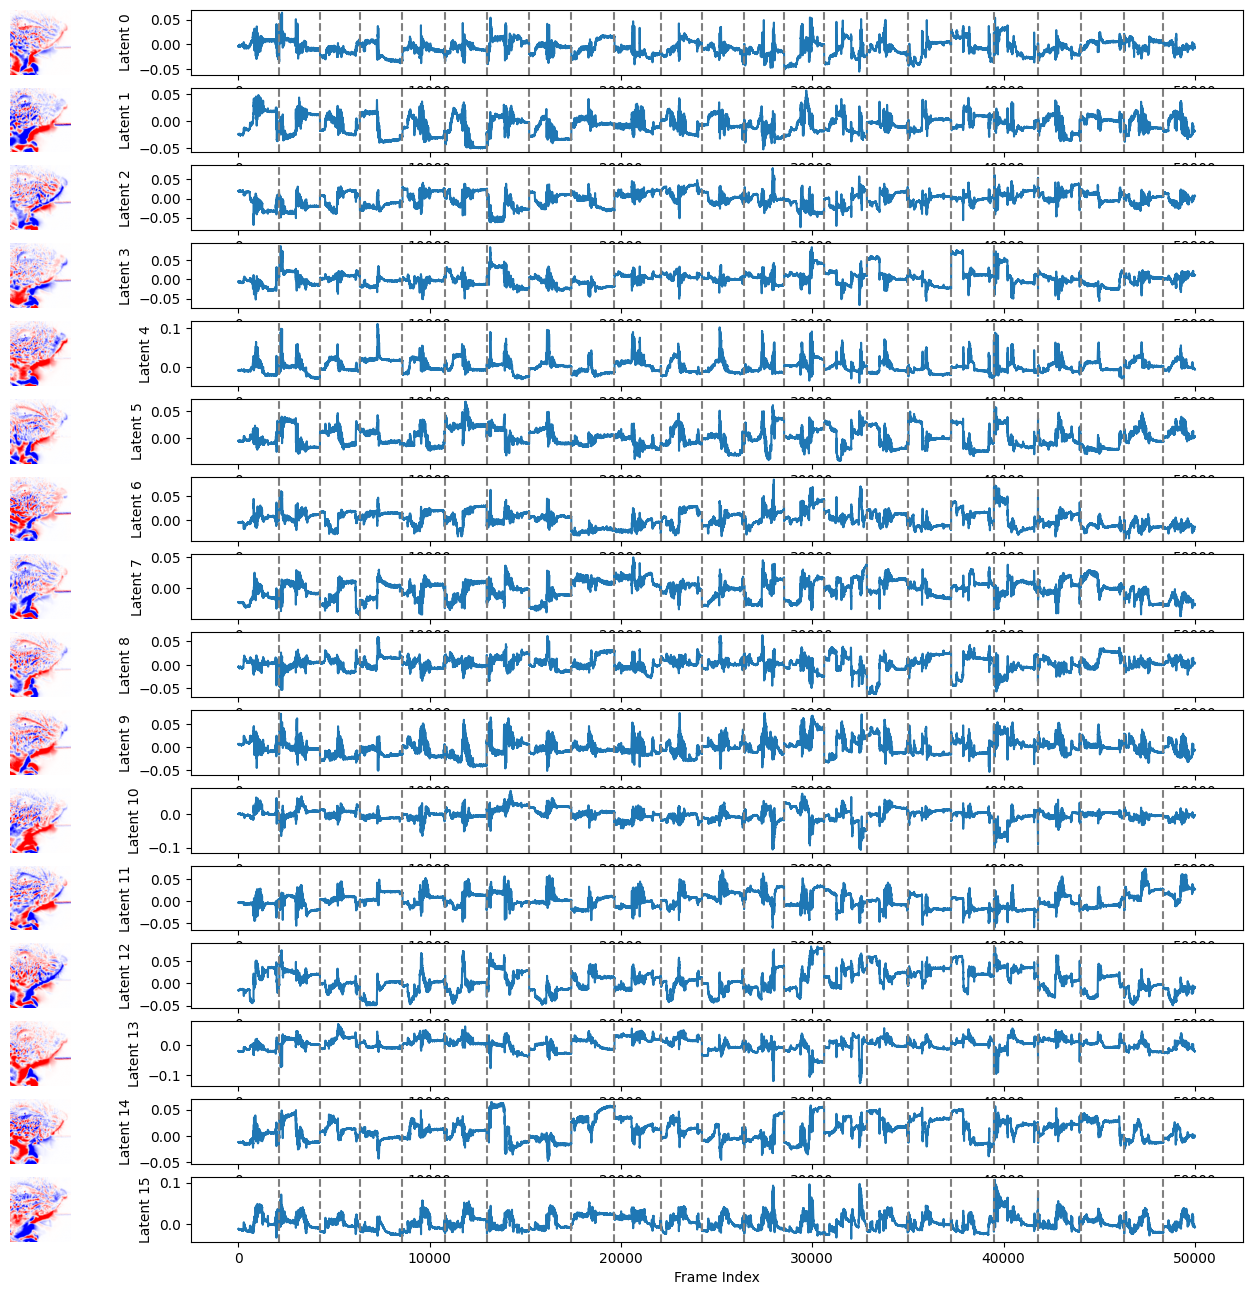

In [50]:
f, axs = plt.subplots(16,2, figsize = (16,16),width_ratios=[1,14]) 

for i in range(16):
    input = torch.zeros((1,1,16))
    input[0,0,i] = 1

    with torch.no_grad():
        latent_image = ae.decoder(input)
        latent_image = latent_image.squeeze().numpy()
    axs[i,0].imshow(latent_image, cmap='bwr', vmin=-1, vmax=1)
    axs[i,1].set_ylabel(f"Latent {i}")
    axs[i,0].axis('off')

    axs[i,1].plot(inference_data['latents'][:50000].squeeze()[:,i])
    for xx_lim in np.where(np.diff(inference_data['trial_ids'][:50000]) != 0)[0]:
        axs[i,1].axvline(xx_lim, color='gray', linestyle='--')
    if i == 15:
        axs[i,1].set_xlabel("Frame Index")

plt.savefig(os.path.join(figfolder, 'decoder_latent_visualization_with_traces_newcrop_v2_lossmask.png'), bbox_inches='tight', dpi = 300)

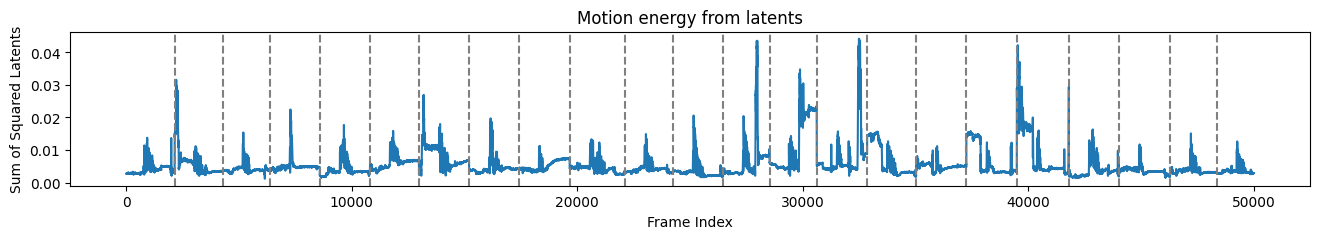

In [51]:
f, ax = plt.subplots(1,1, figsize = (16,2))

ax.plot((inference_data['latents'][:50000].squeeze()**2).sum(axis=1))
for xx_lim in np.where(np.diff(inference_data['trial_ids'][:50000]) != 0)[0]:
    ax.axvline(xx_lim, color='gray', linestyle='--')

ax.set_xlabel("Frame Index")
ax.set_ylabel("Sum of Squared Latents")
ax.set_title("Motion energy from latents")

plt.savefig(os.path.join(figfolder, 'latent_motion_energy_newcrop_v2_lossmask.png'), bbox_inches='tight', dpi = 300)

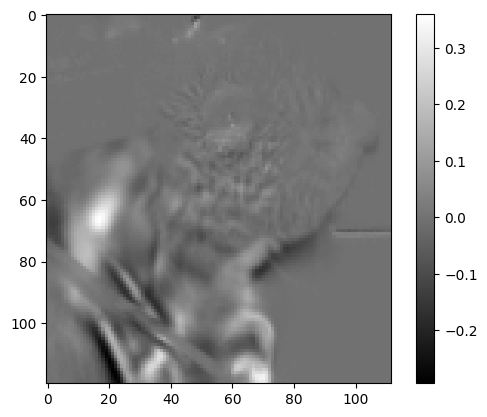

In [13]:
plt.imshow(inference_data['reconstructions'][1].squeeze()/255.0 - inference_data['mean_frame'][:].squeeze(), cmap='gray')
plt.colorbar()

In [18]:
unique_trials = np.unique(inference_data['trial_ids'])
print(f"Unique trial IDs in inference data: {unique_trials}")

Unique trial IDs in inference data: [ 15  17  19  21  23  25  27  29  31  33  35  37  39  41  43  45  47  49
  51  53  55  57  59  61  63  65  67  69  71  73  75  77  79  81  83  85
  87  89  91  93  95  99 101 103 105 107 109 111 113 115 117 119 121 123
 125 127 129 131 133 135 137 139 141 143 145 147 149 151 153 155 157 159
 161 163 165 167 169 171 173 175 177 179 181 183 185 187 191 193 195 197
 199 201 203 205 207 209 211 213 215 217 219 221 223 225 227 229 231 233
 235 237 239 241 243 245 247 249 251 253 255 257 259 261 263 265 267 269
 273 275 277 279 281 283 285 287 291 293 295 297 299 301 303 305 307 309
 311 313 315 317 319 321 323 325 327 329 331 333 335 337 339 341 343 345
 347 349 351 353]


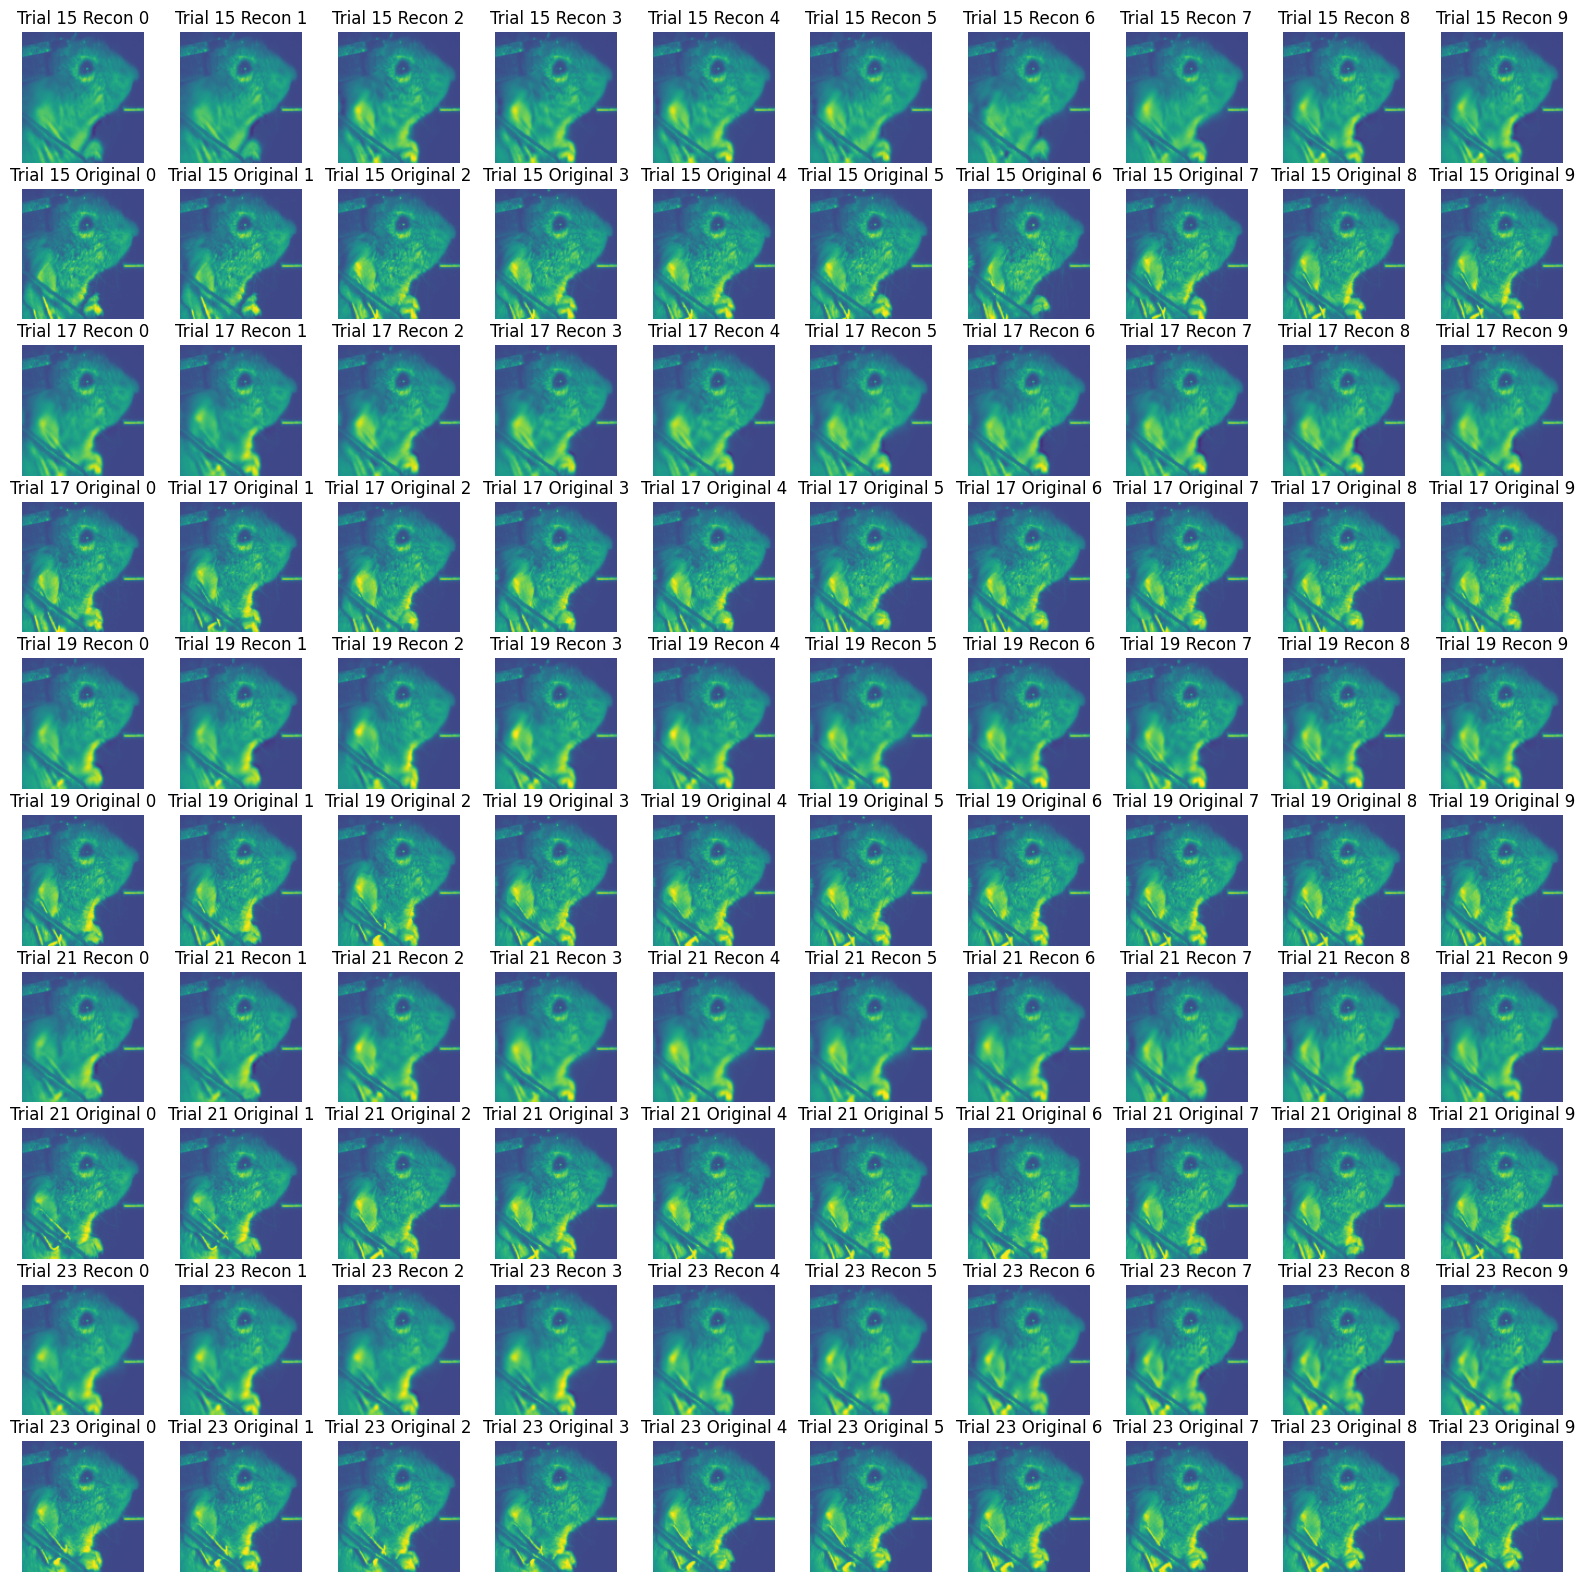

In [27]:
example_trial_ids = unique_trials[:5]

n_example_frames = 10

fig, axs = plt.subplots(len(example_trial_ids)*2, n_example_frames, figsize=(20, 20))

for i, trial_id in enumerate(example_trial_ids):
    inference_trial_inds = np.where(inference_data['trial_ids'][:] == trial_id)[0]
    original_trial_inds = np.where(original_data['trial_ids'][:] == trial_id)[0]
    assert len(inference_trial_inds) == len(original_trial_inds), f"Trial {trial_id} has different number of frames in inference vs original data"
    frame_inds_within_trial = np.linspace(0, len(inference_trial_inds)-1, n_example_frames).astype(int)
    inference_frames = inference_data['reconstructions'][inference_trial_inds]
    trial_recons = inference_frames[frame_inds_within_trial]
    original_frames = original_data['frames'][original_trial_inds]
    original_trial_frames = original_frames[frame_inds_within_trial]

    for j in range(n_example_frames):
        if j < len(trial_recons):
            axs[i*2, j].imshow(trial_recons[j].squeeze(), cmap='viridis', vmin=0, vmax=255)
            axs[i*2, j].set_title(f"Trial {trial_id} Recon {j}")
            axs[i*2, j].axis('off')

        if j < len(original_trial_frames):
            axs[i*2+1, j].imshow(original_trial_frames[j].squeeze(), cmap='viridis', vmin=0, vmax=255)
            axs[i*2+1, j].set_title(f"Trial {trial_id} Original {j}")
            axs[i*2+1, j].axis('off')

plt.savefig(figfolder + 'example_original_and_reconstructed_images.png', bbox_inches='tight', dpi=300)

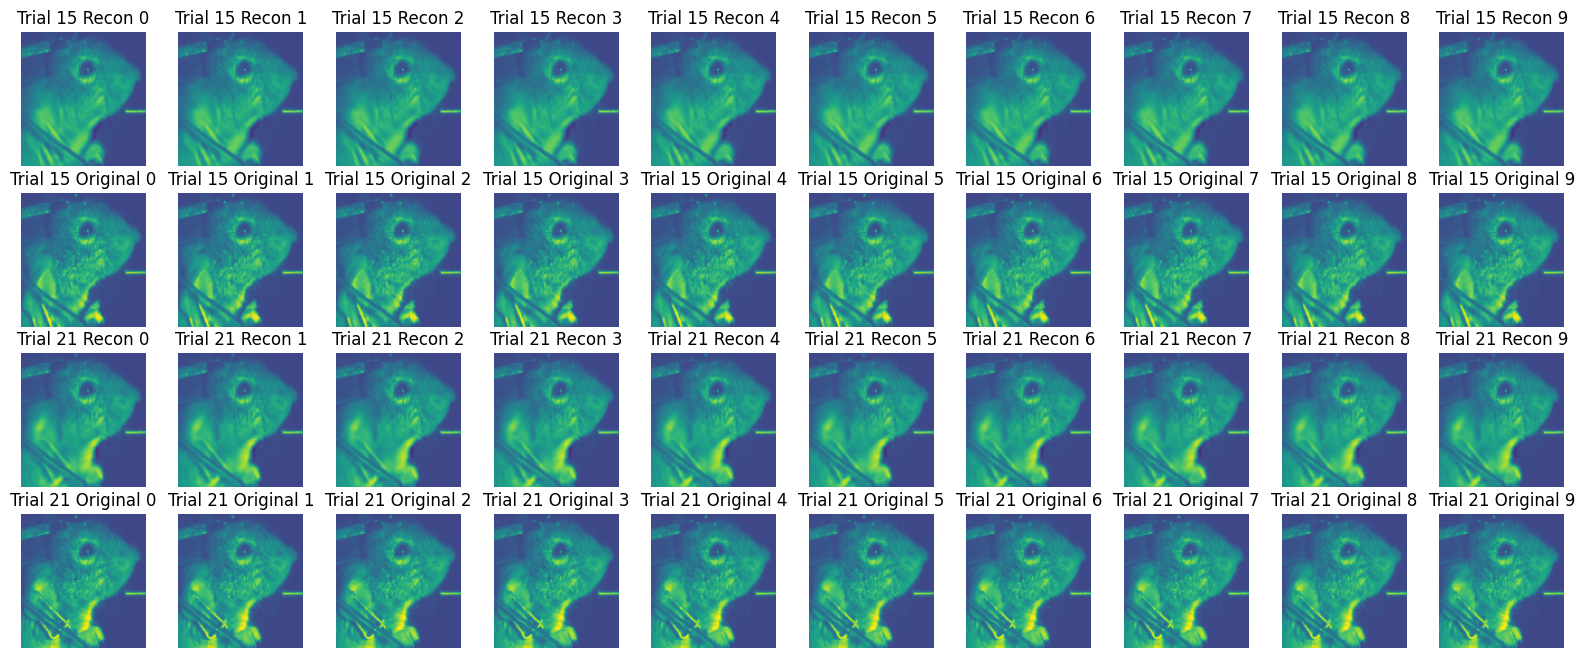

In [34]:
example_trial_ids = [15,21] #unique_trials[:2]

n_example_frames = 10

fig, axs = plt.subplots(len(example_trial_ids)*2, n_example_frames, figsize=(20, 8))

for i, trial_id in enumerate(example_trial_ids):
    inference_trial_inds = np.where(inference_data['trial_ids'][:] == trial_id)[0]
    original_trial_inds = np.where(original_data['trial_ids'][:] == trial_id)[0]
    assert len(inference_trial_inds) == len(original_trial_inds), f"Trial {trial_id} has different number of frames in inference vs original data"
    frame_inds_within_trial = np.linspace(0, n_example_frames-1, n_example_frames).astype(int)
    inference_frames = inference_data['reconstructions'][inference_trial_inds]
    trial_recons = inference_frames[frame_inds_within_trial]
    original_frames = original_data['frames'][original_trial_inds]
    original_trial_frames = original_frames[frame_inds_within_trial]

    for j in range(n_example_frames):
        if j < len(trial_recons):
            axs[i*2, j].imshow(trial_recons[j].squeeze(), cmap='viridis', vmin=0, vmax=255)
            axs[i*2, j].set_title(f"Trial {trial_id} Recon {j}")
            axs[i*2, j].axis('off')

        if j < len(original_trial_frames):
            axs[i*2+1, j].imshow(original_trial_frames[j].squeeze(), cmap='viridis', vmin=0, vmax=255)
            axs[i*2+1, j].set_title(f"Trial {trial_id} Original {j}")
            axs[i*2+1, j].axis('off')

plt.savefig(figfolder + 'example_original_and_reconstructed_images_2trial.png', bbox_inches='tight', dpi=300)

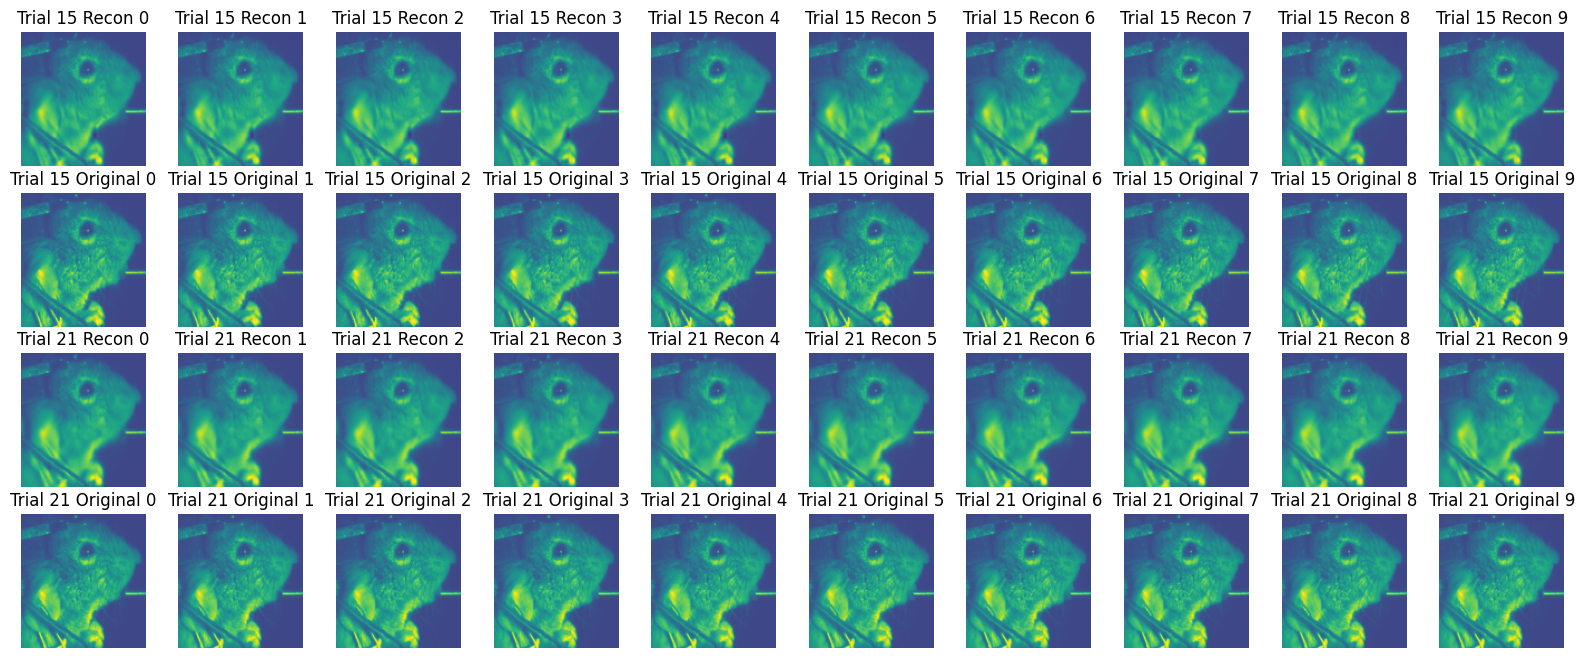

In [33]:
example_trial_ids = [15,21] #unique_trials[:2]

n_example_frames = 10

fig, axs = plt.subplots(len(example_trial_ids)*2, n_example_frames, figsize=(20, 8))

for i, trial_id in enumerate(example_trial_ids):
    inference_trial_inds = np.where(inference_data['trial_ids'][:] == trial_id)[0]
    original_trial_inds = np.where(original_data['trial_ids'][:] == trial_id)[0]
    assert len(inference_trial_inds) == len(original_trial_inds), f"Trial {trial_id} has different number of frames in inference vs original data"
    frame_inds_within_trial = np.linspace(0, n_example_frames-1, n_example_frames).astype(int)+1000
    inference_frames = inference_data['reconstructions'][inference_trial_inds]
    trial_recons = inference_frames[frame_inds_within_trial]
    original_frames = original_data['frames'][original_trial_inds]
    original_trial_frames = original_frames[frame_inds_within_trial]

    for j in range(n_example_frames):
        if j < len(trial_recons):
            axs[i*2, j].imshow(trial_recons[j].squeeze(), cmap='viridis', vmin=0, vmax=255)
            axs[i*2, j].set_title(f"Trial {trial_id} Recon {j}")
            axs[i*2, j].axis('off')

        if j < len(original_trial_frames):
            axs[i*2+1, j].imshow(original_trial_frames[j].squeeze(), cmap='viridis', vmin=0, vmax=255)
            axs[i*2+1, j].set_title(f"Trial {trial_id} Original {j}")
            axs[i*2+1, j].axis('off')

plt.savefig(figfolder + 'example_original_and_reconstructed_images_2trial_v2.png', bbox_inches='tight', dpi=300)

In [20]:
checkpoint_folder = '/home/kurgyis/Research/VideoAnalysisTools/data/checkpoints/kd115/kd115_twNew_20221206_115814_2026-06-23_19-07-46/'
checkpoint_name = 'checkpoint_epoch_2499.pt'

checkpoint_path = os.path.join(checkpoint_folder, checkpoint_name)

checkpoint = torch.load(checkpoint_path,weights_only=False)

In [21]:
checkpoint.keys()


dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'config', 'val_loss', 'mean_frame_train', 'mean_frame_val', 'train_losses', 'val_losses', 'val_recon_losses', 'val_latent_losses', 'lr_history'])

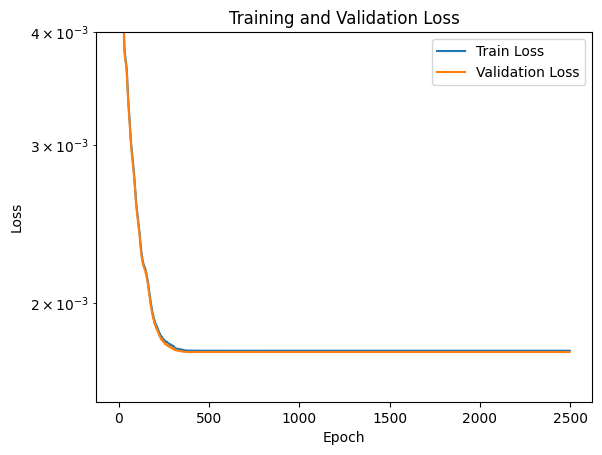

In [23]:
plt.plot(checkpoint['train_losses'], label='Train Loss')
plt.plot(checkpoint['val_losses'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.yscale('log')
plt.ylim(None, 0.004)
plt.savefig(os.path.join(figfolder, 'training_validation_loss.png'), bbox_inches='tight', dpi=300)
plt.show()